# 📈 Linear Regression

**Linear regression** is a statistical technique used to **model and analyze** the relationship between:
- A **dependent variable** (*target*) — the value we want to predict.
- One or more **independent variables** (*features*) — the inputs we believe influence the target.

The goal is to find the **best-fitting straight line** (or **hyperplane** in higher dimensions) ➖ that predicts the target variable based on the input features.

## 🔹 Types of Linear Regression
- **Simple Linear Regression** → Models the relationship between **two variables** using a straight line.  
- **Multiple Linear Regression** → Models the relationship between **one target** and **multiple features**.

## 🎯 Common Use Cases
-  Predicting **house prices**  
- Estimating **sales** based on advertising spend  
- Forecasting **trends** over time  

## ⚙️ How It Works
Linear regression tries to find a line that fits the data points **as closely as possible**, by **minimizing the error** (distance) between the **actual values** and the **predicted values** 📉.

Mathematically, the model can be expressed as:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n + \varepsilon
$$

Where:
- **β₀** → Intercept  
- **β₁, β₂, …** → Coefficients (impact of each feature)  
- **ε** → Error term (unexplained variation)


## ⚙️⚙️ How Can we train Our Linear Regression Model? ⚙️⚙️
1. Gather datas and store them into a dataset
2. Do a Study of various values in the dataset to find relationships, outliers ecc.. (eventually we can do features engienniering)
3. Divide into target and features(in other cases we should also divide in training set and evaluation set)
4. Apply standardization to features dataframe
5. Train The model
6. Evaluate results

# Data Preparations :

In [36]:
import pandas as pd
import numpy as np

df = pd.read_csv('usa_houses.csv')
df = df[(df['price'] < 2700000) & (df['price'] > 10000)] # removing outliers 

# Finding relationships in the datas :

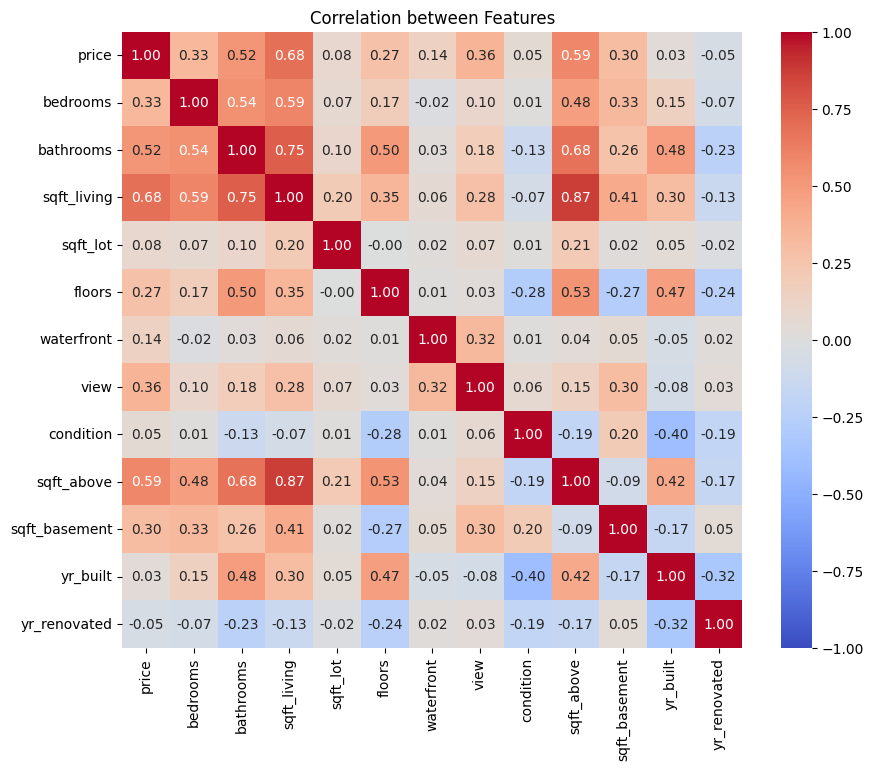

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Features')
plt.show()

### Dividing in Target dataset and Features dataset and choosing our features

**📂 Training, Validation, and Test Sets**  
In machine learning, we  usuallytypically split our dataset
into three parts to ensure fair training and unbiased evaluation.  

**🏋️ Training Set :** The portion of the data used to **teach** the model.   
The model adjusts its internal parameters based on this data to learn patterns and relationships.

**🧪 Validation Set :**
A separate subset used **during training** to check how well the model generalizes to unseen data.  
It helps in **tuning hyperparameters** and making model selection decisions without touching the test set.

**📝 Test Set :**
A final, untouched portion of the data used **only after training is complete**.  
It provides an **unbiased estimate** of the model’s real-world performance.

In [38]:
features_df = df[['sqft_living', 'bedrooms', 'floors', 'view']]
target_df = df['price']

# Standardization of our Features Dataset

Why we do Standardization/ scaling only on the training/ features set because:  
In machine learning, data leakage happens when information that wouldn’t be available at prediction time accidentally ends up in the training data.  
This gives the model an unfair advantage during training and validation, making it look far more accurate than it will be in the real world.  
If we standardize both sets (training , target) we are influencing the results


In [39]:
from sklearn.preprocessing import RobustScaler

standardized_matrix = RobustScaler().fit_transform(features_df)
standardized_features_df = pd.DataFrame(standardized_matrix, columns=features_df.columns, index=features_df.index)

# Training Linear Regression Model

In [40]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()
linear_regression_model.fit(standardized_features_df, target_df)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Getting our predictions

In [41]:
y_pred = linear_regression_model.predict(features_df)      

# Interpreting our results(linear model Stats)

**📊 Regression Model Evaluation Metrics**:

1. **R² (Coefficient of Determination)** – How much of the variation in the target variable our model explains.
2. **MSE (Mean Squared Error)** – The average squared difference between predictions and actual values.
3. **RMSE (Root Mean Squared Error)** – Like MSE, but in the same units as the target variable.

In [42]:
mse = np.mean((target_df - y_pred)**2)
rmse = np.sqrt(mse)
r2 = linear_regression_model.score(features_df, target_df)
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error (MSE): 405940561468988288.00
Root Mean Squared Error (RMSE): 637134649.40
R² Score: -3789830.7047


# 📉 Linear regression limits

**Linearity**
The model assumes straight‑line relationships between predictors and the target.  
 When the true relationship is curved or involves interactions, systematic errors appear, often visible as patterns in residuals. Consider feature transformations,  
interaction/polynomial terms, or more flexible models.

**Independence of errors**
Residuals should not be correlated across observations. In time or space, clustered errors make uncertainty look smaller than it is,   
undermining p‑values and confidence. Model the dependence (e.g., time‑series methods, clustered/robust errors) when it’s present.  

**Normality of errors**
Approximate normal residuals enable trustworthy confidence intervals and hypothesis tests.  
 Non‑normal, skewed, or heavy‑tailed errors can distort inference even if predictions seem fine.  
  Use transformations, larger samples, robust or bootstrap inference when needed.

**Homoscedasticity**
Error variance should be roughly constant across prediction levels. If variance fans out or shrinks,  
standard errors and risk assessments become unreliable. Diagnose with residual plots and consider target transforms,  
 weighted least squares, or modeling variance.

**Multicollinearity**
Highly correlated predictors make coefficients unstable and hard to interpret, inflating standard errors.  
 Prediction may remain okay, but attribution becomes shaky and signs can flip with small data changes.   
 Reduce redundancy (drop/combine features), regularize, or use dimension reduction.
